EEP 509, Privacy-Preserving Machine Learning, Spring 2026

## Lab 2: Differential Privacy

##### This lab consists of the following sections:
- Part 1: Background and Setup ( Optional — 0 points )
- Part 2: DP Foundations — Mechanisms and Sensitivity ( 10 points )
- Part 3: Privacy Accounting and Composition ( 8 points )
- Part 4: Local Differential Privacy ( 12 points )
- Part 5: DP-SGD — Privacy-Preserving Model Training ( 20 points )

##### Grading rubric: for each subquestion
100% of the points - Correct code, correct output<br>
50% of the points - Minor logical error, partial output<br>
0% of the points - No attempt, incomplete code, wrong output

##### Submission instructions

You will have to submit the completed Jupyter notebook file (.ipynb) in Canvas.

## Part 1: Background and Setup ( 0 points )

This section is optional. Please proceed to Part 2 if you are already familiar with
the formal definition of differential privacy.

---

### 1.1 Differential Privacy — Formal Definition

A randomized mechanism $\mathcal{M}: \mathcal{D} \to \mathcal{R}$ satisfies
**$(\varepsilon, \delta)$-differential privacy** if, for every pair of neighbouring
datasets $D, D'$ (differing in at most one record) and every measurable output set
$S \subseteq \mathcal{R}$:

$$\Pr[\mathcal{M}(D) \in S] \;\leq\; e^{\varepsilon} \cdot \Pr[\mathcal{M}(D') \in S] + \delta$$

The parameter $\varepsilon \geq 0$ (the **privacy budget**) controls how much the
output distribution can differ between neighboring datasets — smaller $\varepsilon$
means stronger privacy. $\delta \geq 0$ is the failure probability; setting $\delta=0$
gives **pure** $\varepsilon$-DP.

---

### 1.2 Sensitivity

The **$\ell_1$-sensitivity** of a query $f: \mathcal{D} \to \mathbb{R}^k$ is:

$$\Delta_1 f = \max_{D, D' \text{ neighbors}} \|f(D) - f(D')\|_1$$

It measures the worst-case change in the query output caused by adding or removing
one individual. The **Laplace mechanism** achieves $\varepsilon$-DP by adding noise
sampled from $\text{Lap}(0,\, \Delta_1 f / \varepsilon)$ to each output coordinate.
The **Gaussian mechanism** uses $\mathcal{N}(0, \sigma^2)$ noise with
$\sigma = \Delta_2 f \cdot \sqrt{2 \ln(1.25/\delta)} / \varepsilon$ to achieve
$(\varepsilon, \delta)$-DP.

---

### 1.3 Composition

**Sequential composition**: if $\mathcal{M}_1$ is $(\varepsilon_1, \delta_1)$-DP and
$\mathcal{M}_2$ is $(\varepsilon_2, \delta_2)$-DP and they are applied to the same
dataset, their composition is $(\varepsilon_1+\varepsilon_2,\, \delta_1+\delta_2)$-DP.

**Post-processing**: applying any (randomised) function to the output of a DP mechanism
does not weaken privacy — the result is still $(\varepsilon, \delta)$-DP.

---

### 1.4 Local Differential Privacy

In the **local model**, each user applies a randomized response mechanism to their
own data *before* sending it to an (untrusted) aggregator. A mechanism
$\mathcal{M}$ satisfies **$\varepsilon$-LDP** if for every pair of input values
$v, v'$ and every output $y$:

$$\Pr[\mathcal{M}(v) = y] \leq e^\varepsilon \cdot \Pr[\mathcal{M}(v') = y]$$

The classical mechanism is **randomised response**: a user with a sensitive binary
attribute reports their true value with probability $p = e^\varepsilon / (1 + e^\varepsilon)$
and the opposite value otherwise.

---

### 1.5 Setup

In [3]:
# Setup — run this cell first

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets        import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import MinMaxScaler
from sklearn.metrics         import accuracy_score

torch.manual_seed(42)
np.random.seed(42)
print('Libraries loaded successfully.')

Libraries loaded successfully.


## Part 2: DP Foundations — Mechanisms and Sensitivity ( 10 points )

In this part, you will implement and analyse the core noise-addition mechanisms
that underpin differential privacy.

Look out for the `# YOUR CODE HERE:` comment in the following cells.

In [4]:
# Loading libraries
import numpy as np
import matplotlib.pyplot as plt

### 2.a) The Laplace Mechanism ( 3 points )

The **Laplace mechanism** releases a query result $f(D) \in \mathbb{R}^k$ with
additive Laplace noise calibrated to the query's $\ell_1$-sensitivity $\Delta_1 f$
and the desired privacy budget $\varepsilon$:

$$\mathcal{M}_L(D) = f(D) + (Z_1, \ldots, Z_k), \quad Z_i \sim \text{Lap}\!\left(0,\, \frac{\Delta_1 f}{\varepsilon}\right)$$

The scale of the noise is $b = \Delta_1 f / \varepsilon$.

Implement `laplace_mechanism(true_value, sensitivity, epsilon)` that:
1. Accepts a scalar or NumPy array `true_value`, a scalar `sensitivity` ($\Delta_1 f$),
   and a scalar `epsilon` ($\varepsilon$).
2. Returns the noisy result by adding appropriately scaled Laplace noise.

Then, using a **counting query** (which has $\ell_1$-sensitivity = 1) on a dataset
of 1,000 records, demonstrate empirically how the noise distribution changes as
$\varepsilon \in \{0.1, 0.5, 1.0, 5.0\}$ by plotting overlapping histograms of
10,000 noisy releases for each $\varepsilon$.

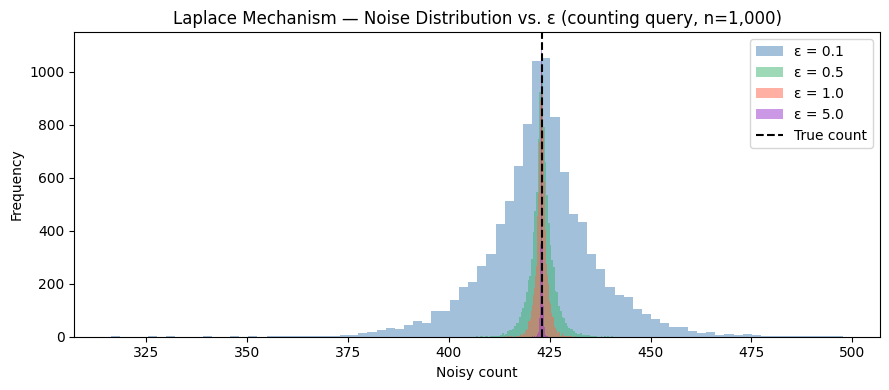

Empirical std of noisy releases (expected = sensitivity/ε * √2):
  ε= 0.1:  empirical std =  14.19  |  expected =  14.14
  ε= 0.5:  empirical std =   2.84  |  expected =   2.83
  ε= 1.0:  empirical std =   1.38  |  expected =   1.41
  ε= 5.0:  empirical std =   0.28  |  expected =   0.28


In [5]:
from matplotlib.pylab import size


def laplace_mechanism(true_value, sensitivity, epsilon):
    """
    Parameters
    ----------
    true_value  : float or np.ndarray — the exact query result.
    sensitivity : float               — l1-sensitivity of the query.
    epsilon     : float               — privacy budget (> 0).

    Returns
    -------
    float or np.ndarray — noisy query result.
    """
    scale = sensitivity / epsilon
    tv_arr = np.asarray(true_value)
    noise = np.random.laplace(loc=0.0, scale=scale, size=tv_arr.shape)
    noisy = tv_arr + noise
    # return scalar if input was scalar
    if tv_arr.shape == ():
        return noisy.item()
    return noisy


def test_2a():
    true_count   = 423          # exact count on a dataset of 1,000 records
    sensitivity  = 1.0          # counting query sensitivity
    epsilons     = [0.1, 0.5, 1.0, 5.0]
    n_trials     = 10_000
    colors       = ['steelblue', 'mediumseagreen', 'tomato', 'darkorchid']

    plt.figure(figsize=(9, 4))
    for eps, col in zip(epsilons, colors):
        releases = [laplace_mechanism(true_count, sensitivity, eps) for _ in range(n_trials)]
        plt.hist(releases, bins=80, alpha=0.5, color=col, label=f'ε = {eps}')
    plt.axvline(true_count, color='black', linestyle='--', linewidth=1.5, label='True count')
    plt.title('Laplace Mechanism — Noise Distribution vs. ε (counting query, n=1,000)')
    plt.xlabel('Noisy count'); plt.ylabel('Frequency')
    plt.legend(); plt.tight_layout(); plt.show()

    print('Empirical std of noisy releases (expected = sensitivity/ε * √2):')
    for eps in epsilons:
        releases = [laplace_mechanism(true_count, sensitivity, eps) for _ in range(n_trials)]
        expected_std = (sensitivity / eps) * np.sqrt(2)
        print(f'  ε={eps:4.1f}:  empirical std = {np.std(releases):6.2f}  |  expected = {expected_std:6.2f}')


test_2a()

### 2.b) The Gaussian Mechanism ( 3 points )

The **Gaussian mechanism** achieves $(\varepsilon, \delta)$-DP by adding Gaussian noise
with standard deviation:

$$\sigma = \frac{\Delta_2 f \cdot \sqrt{2 \ln(1.25 / \delta)}}{\varepsilon}$$

where $\Delta_2 f$ is the $\ell_2$-sensitivity of the query.

Implement `gaussian_mechanism(true_value, l2_sensitivity, epsilon, delta)` following
the same interface as 2.a.

Then, for a query with $\ell_2$-sensitivity $= 1$ and $\delta = 10^{-5}$, plot the
required $\sigma$ as a function of $\varepsilon \in [0.01, 5.0]$, and overlay it with
the Laplace scale $b = \Delta / \varepsilon$ (with $\Delta_1 = \Delta_2 = 1$) to
compare the two mechanisms.

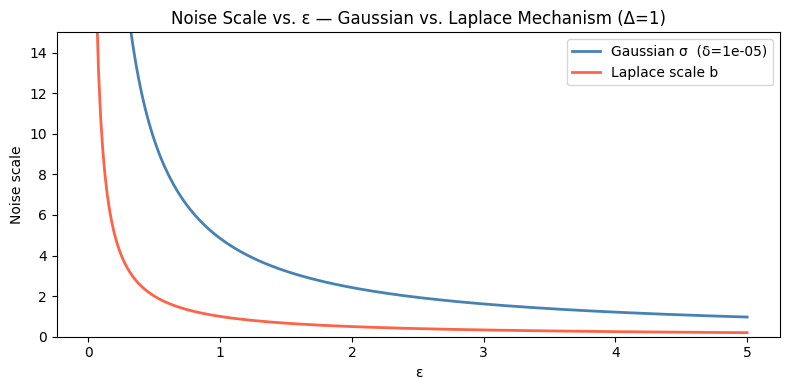

Gaussian mechanism (ε=1.0, δ=1e-05):
  Empirical std = 4.800  |  Expected σ = 4.845


In [6]:
def gaussian_mechanism(true_value, l2_sensitivity, epsilon, delta):
    """
    Parameters
    ----------
    true_value    : float or np.ndarray — exact query result.
    l2_sensitivity: float               — l2-sensitivity of the query.
    epsilon       : float               — privacy budget (> 0).
    delta         : float               — failure probability (0 < delta < 1).

    Returns
    -------
    float or np.ndarray — noisy query result.
    """
    # noisy_value = true_value  # replace with your implementation

    # YOUR CODE HERE:
    sigma = (1.0 * np.sqrt(2 * np.log(1.25 / delta))) / epsilon
    tv_arr = np.asarray(true_value)
    noise = np.random.normal(loc=0.0, scale=sigma, size=tv_arr.shape)
    noisy_value = tv_arr + noise

    # return scalar if input was scalar
    if tv_arr.shape == ():
        return noisy_value.item()

    return noisy_value


def test_2b():
    epsilons = np.linspace(0.01, 5.0, 300)
    delta    = 1e-5

    sigma_gauss  = (1.0 * np.sqrt(2 * np.log(1.25 / delta))) / epsilons
    scale_laplace = 1.0 / epsilons

    plt.figure(figsize=(8, 4))
    plt.plot(epsilons, sigma_gauss,   color='steelblue',      linewidth=2, label=f'Gaussian σ  (δ={delta})')
    plt.plot(epsilons, scale_laplace, color='tomato',         linewidth=2, label='Laplace scale b')
    plt.title('Noise Scale vs. ε — Gaussian vs. Laplace Mechanism (Δ=1)')
    plt.xlabel('ε'); plt.ylabel('Noise scale')
    plt.ylim(0, 15); plt.legend(); plt.tight_layout(); plt.show()

    # Verify: empirical std of the Gaussian mechanism
    true_val = 500.0
    test_eps, test_delta = 1.0, 1e-5
    releases = [gaussian_mechanism(true_val, 1.0, test_eps, test_delta) for _ in range(10_000)]
    expected_sigma = (1.0 * np.sqrt(2 * np.log(1.25 / test_delta))) / test_eps
    print(f'Gaussian mechanism (ε={test_eps}, δ={test_delta}):')
    print(f'  Empirical std = {np.std(releases):.3f}  |  Expected σ = {expected_sigma:.3f}')

test_2b()

### 2.c) Sensitivity Analysis ( 4 points )

The sensitivity of a query determines how much noise must be added. In this exercise,
you will compute $\ell_1$-sensitivities analytically and verify them empirically.

Consider a dataset $D = \{x_1, \ldots, x_n\}$ where each $x_i \in [0, 1]$.
Analyse the following three queries:

| Query | Formula | $\ell_1$-sensitivity |
|-------|---------|---------------------|
| $f_1$: Count | $\sum_i \mathbf{1}[x_i > 0.5]$ | |
| $f_2$: Sum | $\sum_i x_i$ | |
| $f_3$: Mean | $\frac{1}{n}\sum_i x_i$ | |

For each query:
1. Fill in the theoretical $\ell_1$-sensitivity in the Markdown cell below.
2. Empirically estimate the sensitivity by generating 50,000 pairs of neighboring
   datasets (differing in exactly one record) and computing
   $\max |f(D) - f(D')|$ across all pairs.

Implement `estimate_sensitivity(query_fn, n=500, n_pairs=50_000)` that returns the
empirical $\ell_1$-sensitivity for a given query function.

In [7]:
def estimate_sensitivity(query_fn, n=500, n_pairs=50_000):
    """
    Empirically estimate the l1-sensitivity of query_fn over datasets of size n.

    Parameters
    ----------
    query_fn : callable — accepts a 1-D np.ndarray in [0,1] and returns a scalar.
    n        : int      — number of records per dataset.
    n_pairs  : int      — number of neighbouring dataset pairs to sample.

    Returns
    -------
    float : empirical maximum |f(D) - f(D')| over all sampled pairs.
    """
    max_diff = 0.0

    # Hint: for each pair, generate a base dataset D, then create D' by
    # replacing one randomly chosen record with a new random value in [0,1].

    # YOUR CODE HERE:
    for _ in range(n_pairs):
        D = np.random.rand(n)  # base dataset
        D_prime = D.copy()
        idx = np.random.randint(n)  # index to replace
        D_prime[idx] = np.random.rand()  # replace with new random value

        diff = abs(query_fn(D) - query_fn(D_prime))
        if diff > max_diff:
            max_diff = diff

    return max_diff


def test_2c():
    n = 500
    f_count = lambda D: np.sum(D > 0.5)
    f_sum   = lambda D: np.sum(D)
    f_mean  = lambda D: np.mean(D)

    queries = [('Count  f1', f_count), ('Sum    f2', f_sum), ('Mean   f3', f_mean)]

    print(f'Empirical sensitivity estimates (n={n}, 50,000 pairs each):')
    for name, fn in queries:
        sens = estimate_sensitivity(fn, n=n)
        print(f'  {name}: empirical Δ₁ ≈ {sens:.5f}')

test_2c()

Empirical sensitivity estimates (n=500, 50,000 pairs each):
  Count  f1: empirical Δ₁ ≈ 1.00000
  Sum    f2: empirical Δ₁ ≈ 0.99856
  Mean   f3: empirical Δ₁ ≈ 0.00199


**Fill in the theoretical $\ell_1$-sensitivities (replace the blanks):**

| Query | Formula | $\ell_1$-sensitivity |
|-------|---------|---------------------|
| $f_1$: Count | $\sum_i \mathbf{1}[x_i > 0.5]$ | *(your answer)* |
| $f_2$: Sum   | $\sum_i x_i$                    | *(your answer)* |
| $f_3$: Mean  | $\frac{1}{n}\sum_i x_i$         | *(your answer)* |

Briefly explain why the mean query has lower sensitivity than the sum query,
and what implication this has for the noise scale needed to achieve the same $\varepsilon$.

## Part 3: Privacy Accounting and Composition ( 8 points )

When a DP mechanism is applied multiple times to the same dataset — as happens in
every training step of DP-SGD — the total privacy cost accumulates. This part
explores three levels of accounting: basic sequential composition, advanced
composition, and a moments-accountant calculation.

Look out for the `# YOUR CODE HERE:` comment in the following cells.

In [8]:
import numpy as np
import matplotlib.pyplot as plt

### 3.a) Sequential and Advanced Composition ( 4 points )

Suppose we apply the same $\varepsilon_0$-DP mechanism $k$ times to the same dataset.

**Basic composition** gives a total budget of $k \varepsilon_0$.

**Advanced composition** (Dwork et al., 2010) gives a tighter bound: for any
$\delta' > 0$, the $k$-fold composition satisfies $(\varepsilon', k\delta_0 + \delta')$-DP
where:

$$\varepsilon' = \sqrt{2k \ln(1/\delta')}\,\varepsilon_0 + k\varepsilon_0(e^{\varepsilon_0}-1)$$

Implement two functions:
- `basic_composition(eps0, k)` → total $\varepsilon$ under basic composition.
- `advanced_composition(eps0, k, delta_prime)` → total $\varepsilon'$ under advanced
  composition.

Then plot both bounds as a function of $k \in [1, 1000]$ for
$\varepsilon_0 = 0.01$ and $\delta' = 10^{-5}$, and find the crossover point where
advanced composition becomes tighter than basic composition.

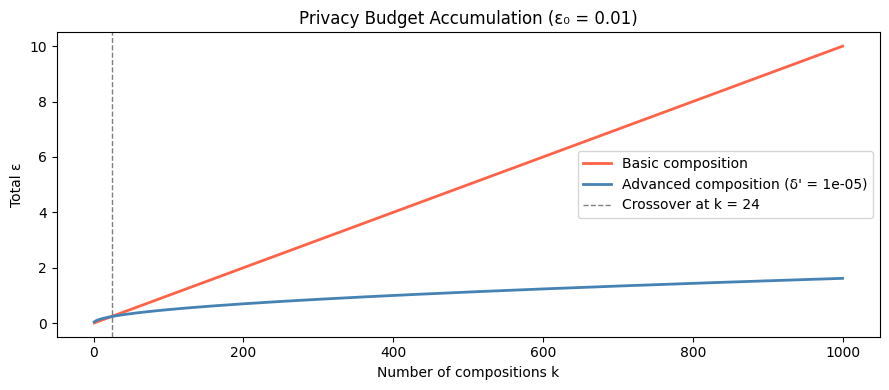

Crossover point: advanced composition becomes tighter at k = 24
At k=1000:  basic = 10.00  |  advanced = 1.62


In [9]:
def basic_composition(eps0, k):
    """
    Returns total epsilon under basic sequential composition.
    """
    # total_eps = 0.0

    # YOUR CODE HERE:
    total_eps = k * eps0

    return total_eps


def advanced_composition(eps0, k, delta_prime):
    """
    Returns total epsilon' under advanced composition (Dwork et al., 2010).
    """
    # eps_prime = 0.0

    # YOUR CODE HERE:
    eps_prime = np.sqrt(2 * k * np.log(1 / delta_prime)) * eps0 + k * eps0 * (np.exp(eps0) - 1)

    return eps_prime


def test_3a():
    eps0         = 0.01
    delta_prime  = 1e-5
    ks           = np.arange(1, 1001)

    basic_eps    = [basic_composition(eps0, k) for k in ks]
    advanced_eps = [advanced_composition(eps0, k, delta_prime) for k in ks]

    # Find crossover point
    crossover = next((k for k, b, a in zip(ks, basic_eps, advanced_eps) if a < b), None)

    plt.figure(figsize=(9, 4))
    plt.plot(ks, basic_eps,    color='tomato',    linewidth=2, label='Basic composition')
    plt.plot(ks, advanced_eps, color='steelblue', linewidth=2, label=f'Advanced composition (δ\' = {delta_prime})')
    if crossover:
        plt.axvline(crossover, color='gray', linestyle='--', linewidth=1,
                    label=f'Crossover at k = {crossover}')
    plt.title(f'Privacy Budget Accumulation (ε₀ = {eps0})')
    plt.xlabel('Number of compositions k'); plt.ylabel('Total ε')
    plt.legend(); plt.tight_layout(); plt.show()

    print(f'Crossover point: advanced composition becomes tighter at k = {crossover}')
    print(f'At k=1000:  basic = {basic_composition(eps0, 1000):.2f}  |  '
          f'advanced = {advanced_composition(eps0, 1000, delta_prime):.2f}')

test_3a()

### 3.b) Privacy Budget for DP-SGD Training ( 4 points )

In DP-SGD, each training step is a mechanism with a per-step privacy cost that
depends on the **noise multiplier** $z$ (the ratio $\sigma / C$, where $C$ is the
gradient clipping norm and $\sigma$ is the Gaussian noise std). A useful
approximation for the per-step $\varepsilon_0$ under subsampled Gaussian noise is:

$$\varepsilon_0 \approx \frac{q \sqrt{2 \ln(1.25/\delta_0)}}{z}$$

where $q = B / N$ is the **sampling ratio** (batch size $B$ over dataset size $N$).

Using **basic composition** over $T$ steps, the total budget is $T \varepsilon_0$.

Implement `dpsgd_epsilon(N, B, z, T, delta0)` that computes the total
$(\varepsilon, T \cdot \delta_0)$-DP budget consumed by $T$ steps of DP-SGD.

Then produce a heatmap showing total $\varepsilon$ as a function of noise multiplier
$z \in [0.5, 3.0]$ and number of training steps $T \in [100, 5000]$, for
$N = 10{,}000$, $B = 256$, $\delta_0 = 10^{-5}$.

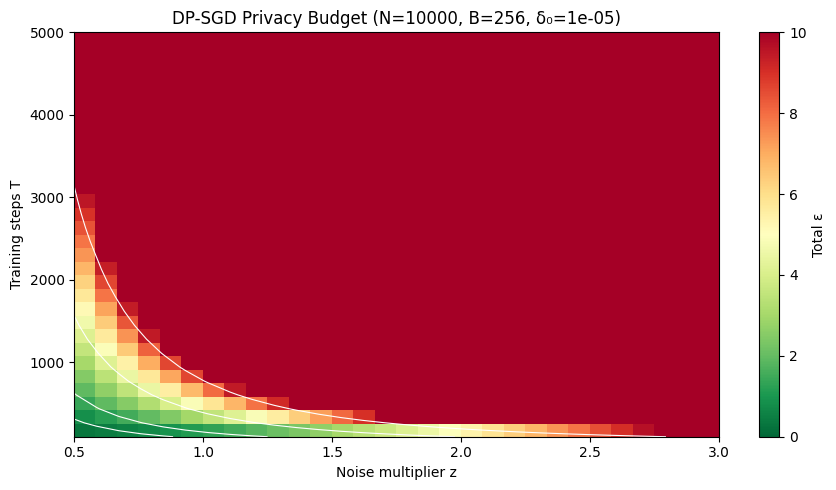

Reference points (total ε):
  z=1.0, T= 500 -> ε = 6.400
  z=1.0, T=1000 -> ε = 12.800
  z=1.0, T=3000 -> ε = 38.400
  z=1.5, T= 500 -> ε = 14.400
  z=1.5, T=1000 -> ε = 28.800
  z=1.5, T=3000 -> ε = 86.400
  z=2.0, T= 500 -> ε = 25.600
  z=2.0, T=1000 -> ε = 51.200
  z=2.0, T=3000 -> ε = 153.600


In [10]:
def dpsgd_epsilon(N, B, z, T, delta0=1e-5):
    """
    Approximate total (epsilon, T*delta0)-DP cost of T steps of DP-SGD.

    Parameters
    ----------
    N      : int   — dataset size.
    B      : int   — batch size.
    z      : float — noise multiplier (sigma / C).
    T      : int   — number of training steps.
    delta0 : float — per-step delta.

    Returns
    -------
    float : total epsilon under basic composition.
    """
    total_eps = 0.0

    # YOUR CODE HERE:
    q = B / N  # sampling ratio
    eps0 = q * z**2 / 2  # per-step epsilon (using moments accountant approximation)
    total_eps = basic_composition(eps0, T)

    return total_eps


def test_3b():
    N, B, delta0 = 10_000, 256, 1e-5
    z_vals = np.linspace(0.5, 3.0, 30)
    T_vals = np.linspace(100, 5000, 30).astype(int)

    heatmap = np.array([[dpsgd_epsilon(N, B, z, T, delta0)
                         for z in z_vals] for T in T_vals])

    plt.figure(figsize=(9, 5))
    im = plt.imshow(heatmap, aspect='auto', origin='lower',
                    extent=[z_vals[0], z_vals[-1], T_vals[0], T_vals[-1]],
                    cmap='RdYlGn_r', vmin=0, vmax=10)
    plt.colorbar(im, label='Total ε')
    plt.contour(z_vals, T_vals, heatmap, levels=[1, 2, 5, 10], colors='white', linewidths=0.8)
    plt.title(f'DP-SGD Privacy Budget (N={N}, B={B}, δ₀={delta0})')
    plt.xlabel('Noise multiplier z'); plt.ylabel('Training steps T')
    plt.tight_layout(); plt.show()

    # Print a few reference points
    print('Reference points (total ε):')
    for z in [1.0, 1.5, 2.0]:
        for T in [500, 1000, 3000]:
            print(f'  z={z}, T={T:4d} -> ε = {dpsgd_epsilon(N, B, z, T, delta0):.3f}')

test_3b()

## Part 4: Local Differential Privacy ( 12 points )

In the **local model** of DP, individuals randomize their own data before
sharing it. This part implements randomized response for binary and categorical
attributes, and studies the accuracy-privacy tradeoff in frequency estimation.

You will use a synthetic population dataset of 10,000 individuals, each with
a binary sensitive attribute (e.g., whether they have a certain medical condition)
and a categorical attribute with 5 possible values.

Look out for the `# YOUR CODE HERE:` comment in the following cells.

In [11]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)

N_POP      = 10_000
TRUE_PREV  = 0.3     # 30% of population has the binary attribute
K_CAT      = 5       # number of categorical values
TRUE_FREQ  = np.array([0.35, 0.25, 0.20, 0.12, 0.08])  # true category frequencies

# Synthetic population
binary_data = (np.random.rand(N_POP) < TRUE_PREV).astype(int)  # 0 or 1
cat_data    = np.random.choice(K_CAT, size=N_POP, p=TRUE_FREQ)

print(f'Population size          : {N_POP}')
print(f'True binary prevalence   : {binary_data.mean():.3f}  (target: {TRUE_PREV})')
print(f'True category frequencies: {np.bincount(cat_data) / N_POP}')

Population size          : 10000
True binary prevalence   : 0.308  (target: 0.3)
True category frequencies: [0.3505 0.2477 0.201  0.1239 0.0769]


### 4.a) Randomized Response for Binary Attributes ( 4 points )

The **randomized response** mechanism for a binary attribute $v \in \{0, 1\}$
satisfies $\varepsilon$-LDP by reporting the true value with probability
$p = e^\varepsilon / (1 + e^\varepsilon)$ and flipping it with probability $1 - p$.

Given noisy reports, the aggregator can obtain an **unbiased estimate** of the
true prevalence using the calibration formula:

$$\hat{\pi} = \frac{\bar{y} - (1-p)}{2p - 1}$$

where $\bar{y}$ is the fraction of users who reported 1.

Implement:
1. `randomised_response(v, epsilon)` — applies the mechanism to a single binary value.
2. `rr_estimate(reports, epsilon)` — given an array of reports and the $\varepsilon$
   used, returns the unbiased prevalence estimate $\hat{\pi}$.

Then, for $\varepsilon \in \{0.1, 0.5, 1.0, 2.0, 5.0\}$, run the full pipeline
10,000 times on samples of size 1,000 and plot the distribution of estimates
$\hat{\pi}$ for each $\varepsilon$.

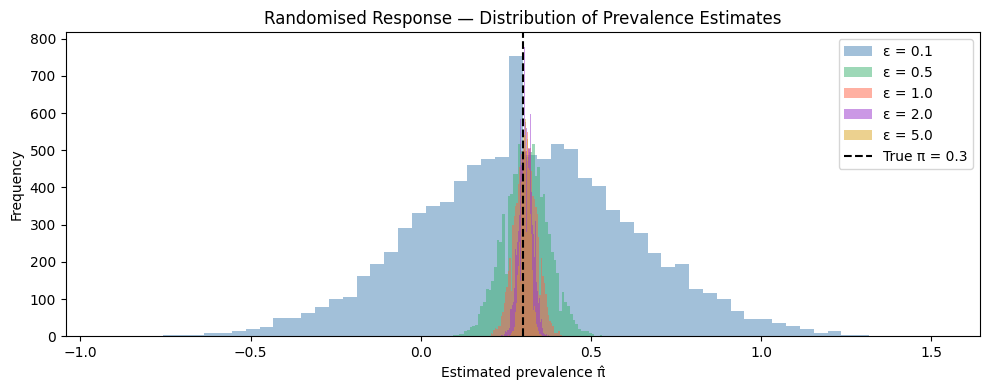

Empirical MSE of prevalence estimates (n=1,000, 10,000 trials):
  ε=0.1: MSE = 0.100966  std = 0.3177
  ε=0.5: MSE = 0.004142  std = 0.0638
  ε=1.0: MSE = 0.001168  std = 0.0332
  ε=2.0: MSE = 0.000437  std = 0.0193
  ε=5.0: MSE = 0.000265  std = 0.0142


In [12]:
def randomised_response(v, epsilon):
    """
    Apply epsilon-LDP randomised response to a binary value v in {0, 1}.

    Parameters
    ----------
    v       : int   — true binary value (0 or 1).
    epsilon : float — LDP privacy budget.

    Returns
    -------
    int : reported value (0 or 1).
    """
    # report = v  # replace with your implementation

    # YOUR CODE HERE:
    p = np.exp(epsilon) / (1 + np.exp(epsilon))  # probability of telling the truth
    if np.random.rand() < p:
        report = v  # tell the truth
    else:
        report = 1 - v  # lie (flip the bit)

    return report


def rr_estimate(reports, epsilon):
    """
    Unbiased estimate of true prevalence from randomised response reports.

    Parameters
    ----------
    reports : np.ndarray — array of reported binary values (0 or 1).
    epsilon : float      — LDP privacy budget used to collect reports.

    Returns
    -------
    float : estimated prevalence pi_hat.
    """
    pi_hat = 0.0

    # YOUR CODE HERE:
    p = np.exp(epsilon) / (1 + np.exp(epsilon))
    pi_hat = (np.mean(reports) - (1 - p)) / (2 * p - 1)

    return pi_hat


def test_4a():
    epsilons  = [0.1, 0.5, 1.0, 2.0, 5.0]
    n_sample  = 1_000
    n_trials  = 10_000
    colors    = ['steelblue', 'mediumseagreen', 'tomato', 'darkorchid', 'goldenrod']

    plt.figure(figsize=(10, 4))
    for eps, col in zip(epsilons, colors):
        estimates = []
        for _ in range(n_trials):
            sample  = binary_data[np.random.choice(N_POP, n_sample, replace=False)]
            reports = np.array([randomised_response(v, eps) for v in sample])
            estimates.append(rr_estimate(reports, eps))
        plt.hist(estimates, bins=60, alpha=0.5, color=col, label=f'ε = {eps}')
    plt.axvline(TRUE_PREV, color='black', linestyle='--', linewidth=1.5, label=f'True π = {TRUE_PREV}')
    plt.title('Randomised Response — Distribution of Prevalence Estimates')
    plt.xlabel('Estimated prevalence π̂'); plt.ylabel('Frequency')
    plt.legend(); plt.tight_layout(); plt.show()

    print('Empirical MSE of prevalence estimates (n=1,000, 10,000 trials):')
    for eps in epsilons:
        ests = []
        for _ in range(n_trials):
            sample  = binary_data[np.random.choice(N_POP, n_sample, replace=False)]
            reports = np.array([randomised_response(v, eps) for v in sample])
            ests.append(rr_estimate(reports, eps))
        mse = np.mean((np.array(ests) - TRUE_PREV) ** 2)
        print(f'  ε={eps:.1f}: MSE = {mse:.6f}  std = {np.std(ests):.4f}')

test_4a()

### 4.b) Generalised Randomized Response for Categorical Data ( 4 points )

For a categorical attribute with $k$ possible values, the **generalised randomized
response** mechanism reports the true value with probability
$p = e^\varepsilon / (e^\varepsilon + k - 1)$ and each other value with probability
$(1-p) / (k-1)$. This satisfies $\varepsilon$-LDP.

The unbiased frequency estimate for category $c$ is:

$$\hat{f}_c = \frac{\bar{y}_c - 1/k}{p - 1/k}$$

where $\bar{y}_c$ is the fraction of users who reported category $c$.

Implement:
1. `grr_response(v, k, epsilon)` — applies generalised randomised response to value $v$.
2. `grr_estimate(reports, k, epsilon)` — returns the unbiased frequency estimate
   for all $k$ categories as a NumPy array.

Then, for $\varepsilon \in \{0.5, 1.0, 3.0\}$, collect reports from the full
population (`cat_data`) and plot estimated vs. true frequencies as grouped bar charts.

ε=0.5: estimated freqs = [0.522 0.393 0.446 0.317 0.265]  |  L1 error = 0.9426
ε=1.0: estimated freqs = [0.409 0.341 0.273 0.214 0.18 ]  |  L1 error = 0.4170
ε=3.0: estimated freqs = [0.353 0.254 0.214 0.133 0.087]  |  L1 error = 0.0415


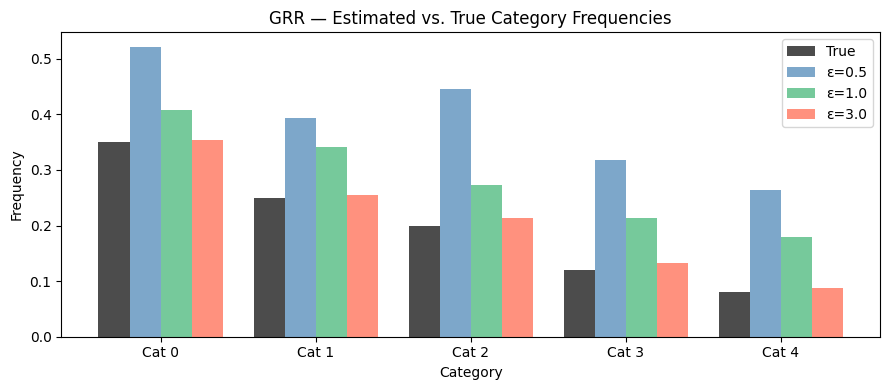

In [13]:
def grr_response(v, k, epsilon):
    """
    Generalised randomised response for a categorical value v in {0, ..., k-1}.

    Parameters
    ----------
    v       : int   — true categorical value.
    k       : int   — number of possible categories.
    epsilon : float — LDP privacy budget.

    Returns
    -------
    int : reported category.
    """
    # report = v  # replace with your implementation

    # YOUR CODE HERE:
    p = np.exp(epsilon) / (np.exp(epsilon) + k - 1)  # probability of telling the truth
    if np.random.rand() < p:
        report = v  # tell the truth
    else:
        report = np.random.choice([i for i in range(k) if i != v])  # lie (choose a different category)
    

    return report


def grr_estimate(reports, k, epsilon):
    """
    Unbiased frequency estimate for all k categories.

    Parameters
    ----------
    reports : np.ndarray — array of reported categories.
    k       : int        — number of categories.
    epsilon : float      — LDP privacy budget used to collect reports.

    Returns
    -------
    np.ndarray, shape (k,) : estimated frequencies (may not sum exactly to 1).
    """
    freq_est = np.zeros(k)

    # YOUR CODE HERE:
    p = np.exp(epsilon) / (np.exp(epsilon) + k - 1)  # probability of telling the truth
    for i in range(k):
        freq_est[i] = (np.mean(reports == i) - (1 - p) / k) / (p - (1 - p) / k)

    return freq_est


def test_4b():
    epsilons = [0.5, 1.0, 3.0]
    x        = np.arange(K_CAT)
    width    = 0.2
    colors   = ['steelblue', 'mediumseagreen', 'tomato']

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(x - 1.5*width, TRUE_FREQ, width, label='True', color='black', alpha=0.7)

    for i, (eps, col) in enumerate(zip(epsilons, colors)):
        reports = np.array([grr_response(v, K_CAT, eps) for v in cat_data])
        est     = grr_estimate(reports, K_CAT, eps)
        ax.bar(x + (i - 0.5)*width, est, width, label=f'ε={eps}', color=col, alpha=0.7)
        l1_err = np.sum(np.abs(est - TRUE_FREQ))
        print(f'ε={eps:.1f}: estimated freqs = {np.round(est, 3)}  |  L1 error = {l1_err:.4f}')

    ax.set_title('GRR — Estimated vs. True Category Frequencies')
    ax.set_xlabel('Category'); ax.set_ylabel('Frequency')
    ax.set_xticks(x); ax.set_xticklabels([f'Cat {i}' for i in range(K_CAT)])
    ax.legend(); plt.tight_layout(); plt.show()

test_4b()

### 4.c) Mean Squared Error vs. ε — Privacy-Utility Tradeoff ( 4 points )

For binary randomized response, the **theoretical variance** of the unbiased
estimator $\hat{\pi}$ (for a sample of size $n$) is:

$$\text{Var}(\hat{\pi}) = \frac{p(1-p)}{n(2p-1)^2}, \quad p = \frac{e^\varepsilon}{1 + e^\varepsilon}$$

Implement `rr_theoretical_variance(epsilon, n)` that computes this quantity.

Then, over $\varepsilon \in [0.1, 5.0]$ and for sample sizes
$n \in \{100, 500, 1{,}000, 5{,}000\}$:
1. Plot the **theoretical variance** as a function of $\varepsilon$ (one curve per $n$).
2. Overlay the **empirical MSE** (from 5,000 simulation trials) for $n=1{,}000$
   to verify your formula.

Below the plot, answer the discussion questions in the Markdown cell.

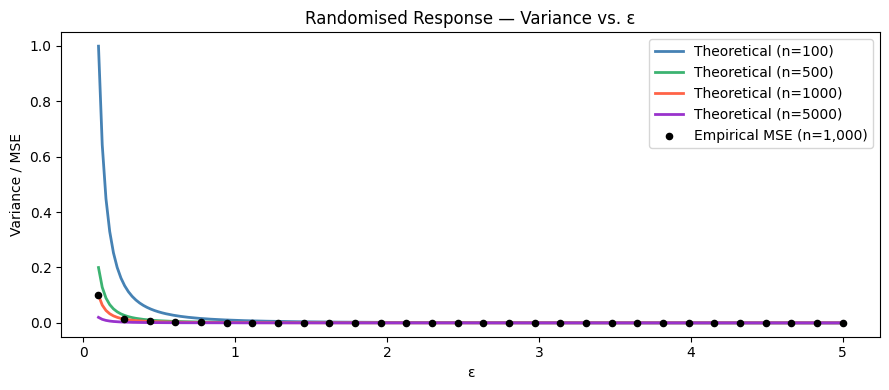

In [16]:
def rr_theoretical_variance(epsilon, n):
    """
    Theoretical variance of the randomised response prevalence estimator.

    Parameters
    ----------
    epsilon : float or np.ndarray — LDP privacy budget.
    n       : int                 — sample size.

    Returns
    -------
    float or np.ndarray : Var(pi_hat).
    """
    # variance = 0.0

    # YOUR CODE HERE:
    p = np.exp(epsilon) / (1 + np.exp(epsilon))  # probability of telling the truth
    variance = (p * (1 - p)) / (n * (2 * p - 1) ** 2)  # variance of the estimator
    return variance


def test_4c():
    epsilons   = np.linspace(0.1, 5.0, 200)
    ns         = [100, 500, 1_000, 5_000]
    colors     = ['steelblue', 'mediumseagreen', 'tomato', 'darkorchid']

    plt.figure(figsize=(9, 4))
    for n, col in zip(ns, colors):
        plt.plot(epsilons, rr_theoretical_variance(epsilons, n),
                 color=col, linewidth=2, label=f'Theoretical (n={n})')

    # Empirical MSE for n=1000
    n_emp  = 1_000
    n_trials = 5_000
    eps_grid = np.linspace(0.1, 5.0, 30)
    emp_mse  = []
    for eps in eps_grid:
        ests = []
        for _ in range(n_trials):
            sample  = binary_data[np.random.choice(N_POP, n_emp, replace=False)]
            reports = np.array([randomised_response(v, eps) for v in sample])
            ests.append(rr_estimate(reports, eps))
        emp_mse.append(np.mean((np.array(ests) - TRUE_PREV)**2))

    plt.scatter(eps_grid, emp_mse, color='black', s=20, zorder=5, label='Empirical MSE (n=1,000)')
    plt.title('Randomised Response — Variance vs. ε')
    plt.xlabel('ε'); plt.ylabel('Variance / MSE')
    plt.legend(); plt.tight_layout(); plt.show()

test_4c()

**Discussion (answer in this cell):**

*Replace this text with your answers.*

1. As $\varepsilon \to \infty$, $p \to 1$ (the mechanism always reports truthfully).
   What does the variance formula reduce to in this limit, and what does this mean
   for the statistical efficiency of the estimator?

2. The theoretical variance blows up as $\varepsilon \to 0$. Explain intuitively
   why extreme privacy ($\varepsilon$ near zero) makes frequency estimation
   arbitrarily inaccurate, regardless of the sample size $n$.

3. If a data collector wants to estimate binary prevalence with MSE $\leq 0.001$
   using $\varepsilon = 1.0$-LDP randomised response, what minimum sample size $n$
   is required? Show your derivation using the variance formula.

## Part 5: DP-SGD — Privacy-Preserving Model Training ( 20 points )

In this part you will implement **DP-SGD** (Abadi et al., 2016) from scratch and
use it to train a classifier on the **Digits dataset**, studying the
privacy-utility tradeoff across a range of noise multipliers.

DP-SGD modifies standard mini-batch SGD in two ways at each step:
1. **Per-sample gradient clipping**: each individual training sample's gradient is
   clipped to $\ell_2$-norm $\leq C$.
2. **Noise addition**: Gaussian noise $\mathcal{N}(0, (zC)^2 \mathbf{I})$ is added
   to the *sum* of clipped gradients before the parameter update.

The sub-questions are:

| Sub-question | Task | Points |
|---|---|---|
| 5.a | Prepare the dataset | 2 |
| 5.b | Implement per-sample gradient clipping | 6 |
| 5.c | Implement the full DP-SGD training loop | 8 |
| 5.d | Privacy-utility tradeoff analysis | 4 |

Look out for the `# YOUR CODE HERE:` comment in each cell.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets        import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import MinMaxScaler

import numpy as np
import matplotlib.pyplot as plt

### 5.a) Prepare the Dataset ( 2 points )

Load the **Digits dataset** (8×8 grayscale images, 10 classes, 1,797 samples).
Scale features to $[0,1]$, use a 70/30 train/test split (`random_state=0`),
and wrap in `DataLoader` objects with `batch_size=64`.

Store:
- `train_loader`, `test_loader` — DataLoader objects
- `X_train_t`, `y_train_t`, `X_test_t`, `y_test_t` — float32 tensors
- `N_TRAIN`, `N_FEATURES` — dataset size and feature count

In [ ]:
# ── Load and scale ────────────────────────────────────────────────────────
digits   = load_digits()
X_all_d  = digits.data.astype(np.float32)
y_all_d  = digits.target

scaler_d = MinMaxScaler()
X_all_d  = scaler_d.fit_transform(X_all_d)

# ── Train / test split ────────────────────────────────────────────────────
# YOUR CODE HERE:


# ── Tensors and DataLoaders ───────────────────────────────────────────────
# YOUR CODE HERE:


# N_TRAIN    = ...
# N_FEATURES = ...

print(f'Train samples : {N_TRAIN}')
print(f'Test samples  : {len(X_test_t)}')
print(f'Features      : {N_FEATURES}')

### 5.b) Per-Sample Gradient Clipping ( 6 points )

Standard PyTorch computes the **average** gradient over a mini-batch, which prevents
per-sample clipping. DP-SGD requires computing each sample's gradient individually,
clipping it to $\ell_2$-norm $\leq C$, and then summing the clipped gradients.

Implement `per_sample_clip_and_sum(model, loss_fn, X_batch, y_batch, C)` that:

1. Computes the gradient of the loss **for each individual sample** in the batch.
2. Clips each per-sample gradient vector to $\ell_2$-norm $\leq C$.
3. Returns the **sum** of all clipped gradients as a list of tensors
   (one per parameter), and the batch size.

*Hint: loop over samples in the batch, compute the scalar loss for that sample,
call `loss.backward()`, collect `param.grad` for all parameters, zero the grads,
then clip and accumulate. Alternatively, use `torch.vmap` or per-sample hooks —
but the loop approach is clearest for understanding.*

In [ ]:
def per_sample_clip_and_sum(model, loss_fn, X_batch, y_batch, C):
    """
    Compute per-sample gradients, clip each to l2-norm <= C, and sum.

    Parameters
    ----------
    model    : nn.Module      — the model being trained.
    loss_fn  : callable       — scalar loss per sample (e.g. nn.CrossEntropyLoss()).
    X_batch  : torch.Tensor   — inputs, shape (B, n_features).
    y_batch  : torch.Tensor   — labels, shape (B,).
    C        : float          — clipping norm.

    Returns
    -------
    clipped_grad_sum : list of torch.Tensor — summed clipped gradients, one per parameter.
    B                : int                  — batch size.
    """
    B = X_batch.shape[0]
    clipped_grad_sum = [torch.zeros_like(p) for p in model.parameters()]

    # YOUR CODE HERE:

    return clipped_grad_sum, B


def test_5b():
    """Verify that per-sample clipping actually clips gradient norms."""
    torch.manual_seed(0)
    test_model = nn.Sequential(nn.Linear(N_FEATURES, 32), nn.ReLU(), nn.Linear(32, 10))
    loss_fn    = nn.CrossEntropyLoss()
    C_test     = 1.0

    X_b, y_b   = next(iter(train_loader))
    y_b        = y_b.long()

    # Compute unclipped per-sample gradient norms manually to compare
    unclipped_norms = []
    for i in range(len(X_b)):
        test_model.zero_grad()
        loss = loss_fn(test_model(X_b[i:i+1]), y_b[i:i+1])
        loss.backward()
        flat = torch.cat([p.grad.flatten() for p in test_model.parameters()])
        unclipped_norms.append(flat.norm().item())

    test_model.zero_grad()
    clipped_sum, B = per_sample_clip_and_sum(test_model, loss_fn, X_b, y_b.long(), C_test)

    print(f'Batch size: {B}')
    print(f'Max unclipped per-sample gradient norm : {max(unclipped_norms):.4f}')
    print(f'Mean unclipped per-sample gradient norm: {np.mean(unclipped_norms):.4f}')
    flat_sum = torch.cat([g.flatten() for g in clipped_sum])
    print(f'l2-norm of summed clipped gradients    : {flat_sum.norm().item():.4f}')
    print(f'(should be <= B * C = {B} * {C_test} = {B * C_test})')

test_5b()

### 5.c) Full DP-SGD Training Loop ( 8 points )

Implement `train_dpsgd(model, train_loader, n_epochs, C, z, lr)` — a complete
DP-SGD training loop that, at each mini-batch step:

1. Calls `per_sample_clip_and_sum` to obtain the sum of clipped gradients.
2. Adds Gaussian noise $\mathcal{N}(0, (z \cdot C)^2 \mathbf{I})$ to the gradient
   **sum** (one independent noise draw per parameter).
3. Divides by the batch size $B$ to obtain the noisy average gradient.
4. Updates each parameter with a standard gradient descent step: $\theta \leftarrow \theta - lr \cdot \tilde{g}$.

After implementing the loop, train models with noise multipliers
$z \in \{0.5, 1.0, 1.5, 2.0, 4.0\}$ and a non-private baseline ($z = 0$,
standard SGD) for 30 epochs each. Record and plot test accuracy vs. epoch
for all runs.

In [ ]:
def train_dpsgd(model, train_loader, n_epochs, C, z, lr=0.05):
    """
    Train a model with DP-SGD.

    Parameters
    ----------
    model        : nn.Module    — model to train (modified in place).
    train_loader : DataLoader   — training data.
    n_epochs     : int          — number of training epochs.
    C            : float        — gradient clipping norm.
    z            : float        — noise multiplier (0 = non-private standard SGD).
    lr           : float        — learning rate.

    Returns
    -------
    list of float : test accuracy at the end of each epoch.
    """
    loss_fn  = nn.CrossEntropyLoss()
    acc_hist = []

    # YOUR CODE HERE:

    return acc_hist


def eval_accuracy(model, X, y):
    model.eval()
    with torch.no_grad():
        preds = model(X).argmax(dim=1)
    return (preds == y).float().mean().item()


def build_model():
    torch.manual_seed(42)
    return nn.Sequential(
        nn.Linear(N_FEATURES, 128), nn.ReLU(),
        nn.Linear(128, 64),         nn.ReLU(),
        nn.Linear(64, 10)
    )


# ── Train models for each noise multiplier ────────────────────────────────
# YOUR CODE HERE:
# For each z in [0, 0.5, 1.0, 1.5, 2.0, 4.0], call train_dpsgd for 30 epochs
# with C=1.0 and lr=0.05. Store results in a dict: {z: acc_history}.

results = {}  # {z_value: [acc_epoch_0, acc_epoch_1, ...]}

# YOUR CODE HERE:


# ── Plot test accuracy vs. epoch ──────────────────────────────────────────
# YOUR CODE HERE:

### 5.d) Privacy-Utility Tradeoff Analysis ( 4 points )

Using the `dpsgd_epsilon` function from Part 3.b and the trained models from 5.c,
compute the total privacy cost for each noise multiplier $z \in \{0.5, 1.0, 1.5,
2.0, 4.0\}$ (use $T = 30 \times \lceil N_{\text{train}} / B \rceil$ total steps,
with $B = 64$ and $\delta_0 = 10^{-5}$).

Then produce a **privacy-utility curve**: a scatter plot of final test accuracy
(y-axis) vs. total $\varepsilon$ (x-axis), with each point labelled by its $z$ value.
Add a horizontal dashed line for the non-private baseline accuracy.

Below the plot, answer the discussion questions.

In [ ]:
# ── Compute (epsilon, accuracy) for each noise multiplier ─────────────────
# YOUR CODE HERE:


# ── Privacy-utility curve ─────────────────────────────────────────────────
# YOUR CODE HERE:

**Discussion (answer in this cell):**

*Replace this text with your answers.*

1. Describe the shape of the privacy-utility curve. Is the accuracy drop gradual
   or is there a sharp cliff at a particular $\varepsilon$ value? What does this
   suggest about choosing a practical operating point?

2. DP-SGD adds noise to gradients, not to the training data directly. Explain
   why this still provides a formal DP guarantee for the released model, and
   how the post-processing property of DP is relevant here.

3. You used basic composition to compute total $\varepsilon$. In practice,
   the moments accountant (or Rényi DP accounting) gives much tighter bounds.
   Based on what you observed in Part 3, by roughly what factor would you expect
   the tighter accountant to reduce the stated $\varepsilon$ for $T = 500$ steps
   at $z = 1.0$?